#**NAME-MEGHNA(11101172024)**
#**Week 3 - Assignment 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

### Loading the Dataset


In [2]:
df = pd.read_csv("/content/agriculture_ml_dataset_cw.csv")
print("Dataset loaded successfully!")


Dataset loaded successfully!



### Part A: Understanding the Dataset

### Q1. Dataset Overview

In [3]:
# Number of rows and columns
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print()

# Column names
print("Column Names:")
print(df.columns.tolist())
print()

# First 10 records
print("First 10 Records:")
df.head(10)


Rows: 2020
Columns: 11

Column Names:
['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation', 'Fertilizer', 'Rainfall', 'Temperature', 'Humidity', 'Nitrogen', 'Yield']

First 10 Records:


,Crop_Type,Soil_Type,Region,Season,Irrigation,Fertilizer,Rainfall,Temperature,Humidity,Nitrogen,Yield
0,Wheat,Silty,South,Kharif,Sprinkler,Chemical,93.7,22.9,69.0,115.0,5.13
1,Cotton,NaN,West,Zaid,Flood,Organic,146.9,25.6,NaN,71.0,5.40
2,Cotton,Clay,North,Kharif,Drip,Chemical,108.7,22.1,NaN,86.0,4.26
3,Maize,Clay,South,Kharif,Sprinkler,Chemical,72.3,26.8,69.4,44.0,4.35
4,Maize,Silty,West,Kharif,Flood,Organic,119.9,26.3,44.3,48.0,4.88
5,Sugarcane,Loamy,West,Rabi,Flood,Mixed,176.4,NaN,83.3,72.0,4.70
6,Wheat,Clay,South,Rabi,Sprinkler,Chemical,146.1,NaN,72.9,97.0,6.82
7,Cotton,Loamy,East,Zaid,NaN,Organic,200.6,26.8,53.6,101.0,6.88
8,Rice,Silty,North,Rabi,Drip,Mixed,136.2,31.3,58.5,111.0,6.26
9,Wheat,Sandy,North,Rabi,Sprinkler,Organic,215.7,26.2,70.8,55.0,6.92


### Q2. Data Types and Missing Values

In [4]:
# Data types
print("Data Types:")
print(df.dtypes)
print()

# Missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
print(missing)
print()

# Affected columns
affected = missing[missing > 0]
if len(affected) > 0:
    print("Columns with missing values:")
    print(affected)
else:
    print("No missing values found.")


Data Types:
Crop_Type       object
Soil_Type       object
Region          object
Season          object
Irrigation      object
Fertilizer      object
Rainfall       float64
Temperature    float64
Humidity       float64
Nitrogen       float64
Yield          float64
dtype: object

Missing Values per Column:
Crop_Type        0
Soil_Type      121
Region           0
Season           0
Irrigation     120
Fertilizer       0
Rainfall       121
Temperature    120
Humidity       122
Nitrogen       121
Yield            0
dtype: int64

Columns with missing values:
Soil_Type      121
Irrigation     120
Rainfall       121
Temperature    120
Humidity       122
Nitrogen       121
dtype: int64


### Q3. Descriptive Statistics

In [5]:
# Summary statistics for numerical features
stats = df.describe()
print(stats)
print()

# Highest mean
highest_mean_col = df.select_dtypes(include=np.number).mean().idxmax()
highest_mean_val = df.select_dtypes(include=np.number).mean().max()
print(f"Feature with highest mean: {highest_mean_col} ({highest_mean_val:.2f})")

# Highest std
highest_std_col = df.select_dtypes(include=np.number).std().idxmax()
highest_std_val = df.select_dtypes(include=np.number).std().max()
print(f"Feature with highest standard deviation: {highest_std_col} ({highest_std_val:.2f})")


          Rainfall  Temperature     Humidity     Nitrogen        Yield
count  1899.000000  1900.000000  1898.000000  1899.000000  2020.000000
mean    129.723960    26.875421    67.740622    79.169036     5.442926
std      35.395931     4.104174    12.046501    22.876734     1.062772
min      22.800000    12.900000    30.600000    40.000000     1.740000
25%     107.100000    24.200000    59.500000    59.000000     4.700000
50%     128.100000    26.900000    67.650000    79.000000     5.430000
75%     153.500000    29.600000    75.800000    99.000000     6.172500
max     245.300000    43.100000   117.800000   119.000000     8.910000

Feature with highest mean: Rainfall (129.72)
Feature with highest standard deviation: Rainfall (35.40)



# Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis — Histograms

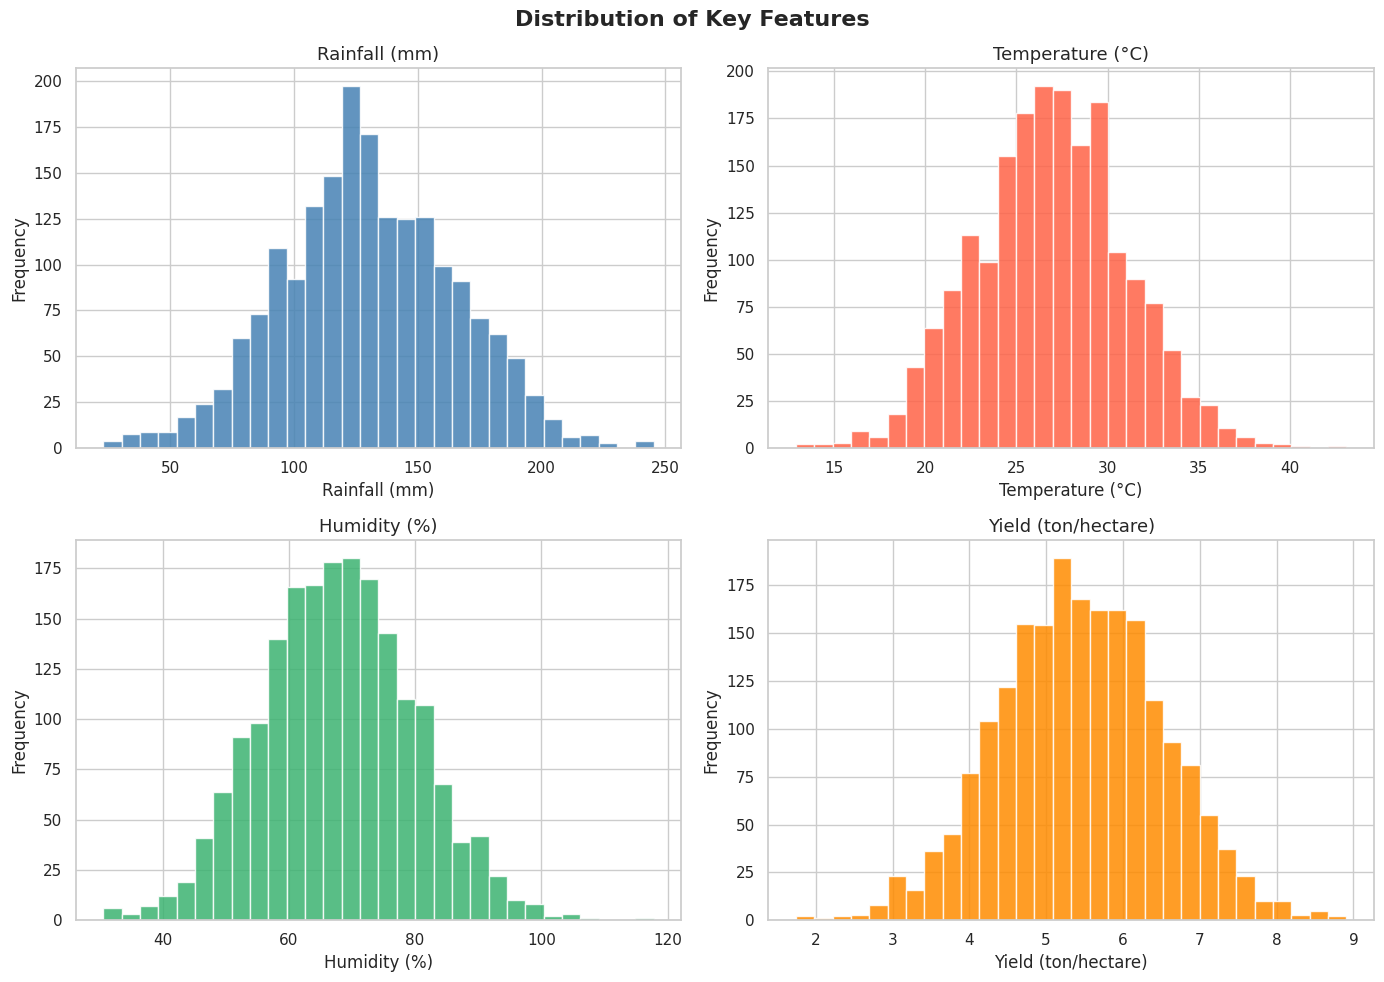


Observations:

Rainfall:
  1. Rainfall is approximately normally distributed, centred around 130 mm.
  2. Most observations fall between 80 mm and 180 mm.
  3. There are a few extreme values beyond 220 mm indicating occasional heavy rainfall.

Temperature:
  1. Temperature shows a roughly bell-shaped distribution centred near 27 °C.
  2. The range spans from about 13 °C to 43 °C, showing wide climatic variation.
  3. Very high temperatures (>40 °C) are rare outliers.

Humidity:
  1. Humidity is approximately normally distributed, peaking around 65–70 %.
  2. Values mostly lie between 40 % and 90 %, showing moderate variation.
  3. A few values exceed 100 %, suggesting possible sensor anomalies or data errors.

Yield:
  1. Yield is approximately normally distributed around 5.4 ton/hectare.
  2. The distribution is slightly right-skewed with a tail toward higher yields.
  3. Yields below 2 ton/hectare or above 8.5 ton/hectare are uncommon.



In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Key Features', fontsize=16, fontweight='bold')

features = ['Rainfall', 'Temperature', 'Humidity', 'Yield']
labels   = ['Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'Yield (ton/hectare)']
colors   = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange']

for ax, feat, label, color in zip(axes.flatten(), features, labels, colors):
    ax.hist(df[feat].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=13)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("""
Observations:

Rainfall:
  1. Rainfall is approximately normally distributed, centred around 130 mm.
  2. Most observations fall between 80 mm and 180 mm.
  3. There are a few extreme values beyond 220 mm indicating occasional heavy rainfall.

Temperature:
  1. Temperature shows a roughly bell-shaped distribution centred near 27 °C.
  2. The range spans from about 13 °C to 43 °C, showing wide climatic variation.
  3. Very high temperatures (>40 °C) are rare outliers.

Humidity:
  1. Humidity is approximately normally distributed, peaking around 65–70 %.
  2. Values mostly lie between 40 % and 90 %, showing moderate variation.
  3. A few values exceed 100 %, suggesting possible sensor anomalies or data errors.

Yield:
  1. Yield is approximately normally distributed around 5.4 ton/hectare.
  2. The distribution is slightly right-skewed with a tail toward higher yields.
  3. Yields below 2 ton/hectare or above 8.5 ton/hectare are uncommon.
""")


### Q5. Crop Type Analysis

Records per Crop Type:
Crop_Type
Maize        426
Wheat        422
Sugarcane    403
Cotton       399
Rice         370
Name: count, dtype: int64

Most frequent crop: Maize (426 records)


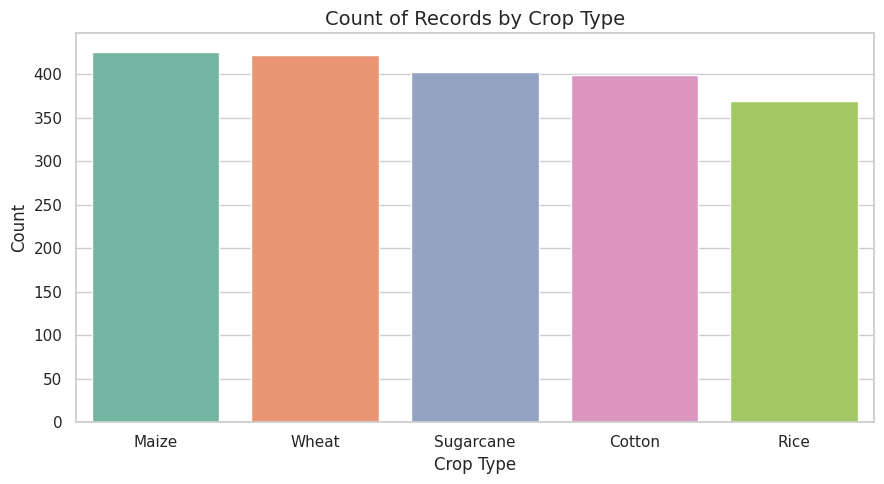

In [7]:
# Record count per crop type
print("Records per Crop Type:")
crop_counts = df['Crop_Type'].value_counts()
print(crop_counts)
print()
print(f"Most frequent crop: {crop_counts.idxmax()} ({crop_counts.max()} records)")

# Count plot
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Crop_Type', palette='Set2',
              order=df['Crop_Type'].value_counts().index)
plt.title('Count of Records by Crop Type', fontsize=14)
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Q6. Soil Type Analysis

Frequency of Each Soil Type:
Soil_Type
Silty    493
Loamy    482
Clay     463
Sandy    461
Name: count, dtype: int64

Most common soil type: Silty (493 records)


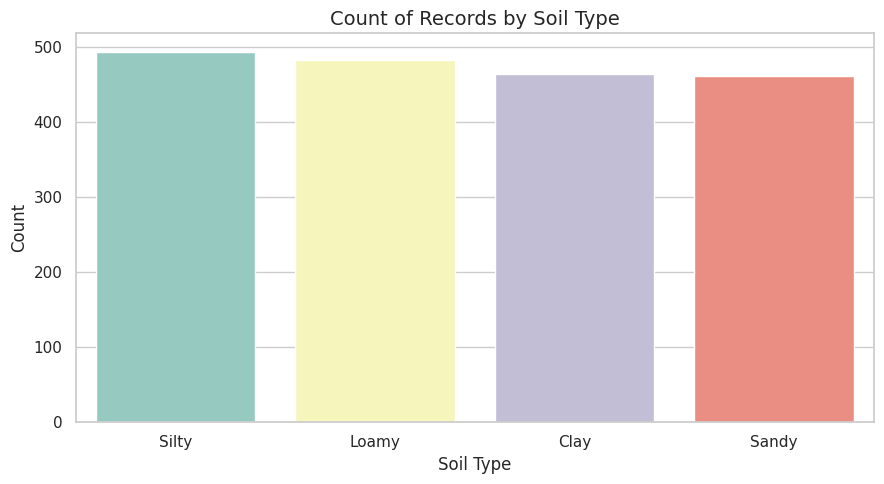

In [8]:
# Frequency per soil type
print("Frequency of Each Soil Type:")
soil_counts = df['Soil_Type'].value_counts()
print(soil_counts)
print()
print(f"Most common soil type: {soil_counts.idxmax()} ({soil_counts.max()} records)")

# Count plot
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Soil_Type', palette='Set3',
              order=df['Soil_Type'].value_counts().index)
plt.title('Count of Records by Soil Type', fontsize=14)
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Q7. Yield Distribution

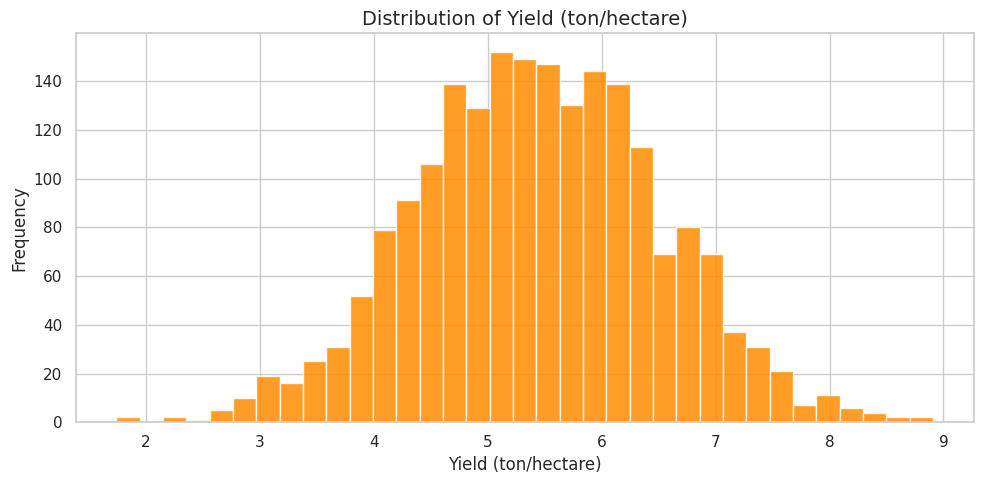

Skewness: 0.0044
Kurtosis: -0.0507

Analysis:
- The distribution is approximately normal (slightly right-skewed).
- No extreme outliers are noticeable; the bulk lies between 3 and 8 ton/hectare.


In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df['Yield'].dropna(), bins=35, color='darkorange', edgecolor='white', alpha=0.85)
plt.title('Distribution of Yield (ton/hectare)', fontsize=14)
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

from scipy import stats as sp_stats
skewness = df['Yield'].skew()
kurtosis = df['Yield'].kurtosis()
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")
print()
print("Analysis:")
print("- The distribution is approximately normal (slightly right-skewed).")
print("- No extreme outliers are noticeable; the bulk lies between 3 and 8 ton/hectare.")


### Q8. Scatter Plot Analysis

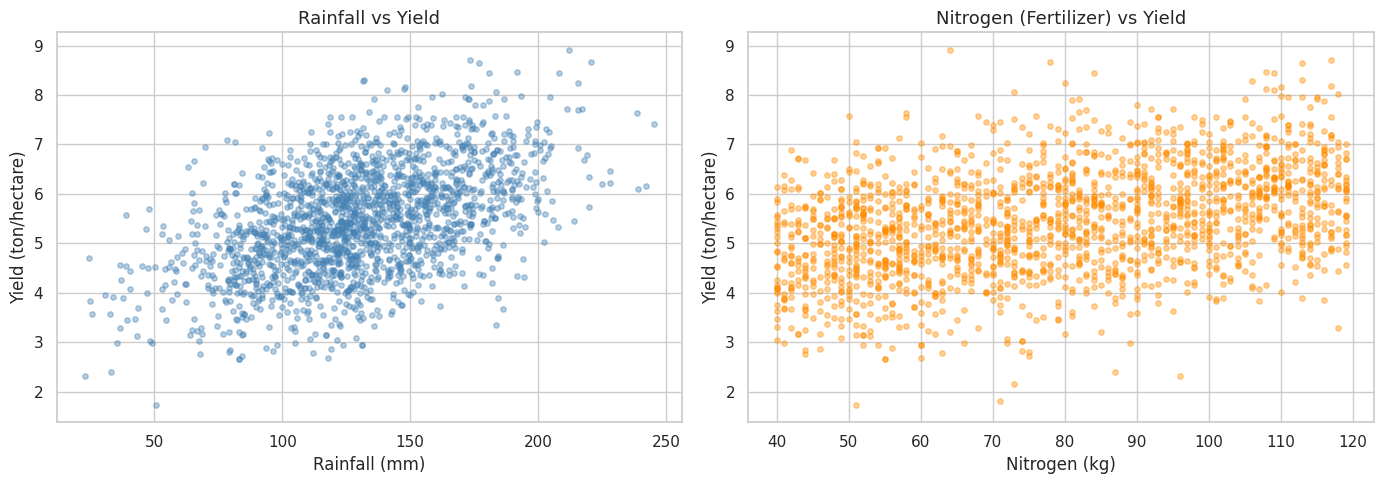

Correlation — Rainfall  vs Yield: 0.4988
Correlation — Nitrogen  vs Yield: 0.3958

Stronger relationship with Yield: Rainfall


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Rainfall'], df['Yield'], alpha=0.4, color='steelblue', s=15)
axes[0].set_title('Rainfall vs Yield', fontsize=13)
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (ton/hectare)')

axes[1].scatter(df['Nitrogen'], df['Yield'], alpha=0.4, color='darkorange', s=15)
axes[1].set_title('Nitrogen (Fertilizer) vs Yield', fontsize=13)
axes[1].set_xlabel('Nitrogen (kg)')
axes[1].set_ylabel('Yield (ton/hectare)')

plt.tight_layout()
plt.show()

# Correlations
r_rainfall  = df[['Rainfall',  'Yield']].corr().iloc[0, 1]
r_nitrogen  = df[['Nitrogen',  'Yield']].corr().iloc[0, 1]
print(f"Correlation — Rainfall  vs Yield: {r_rainfall:.4f}")
print(f"Correlation — Nitrogen  vs Yield: {r_nitrogen:.4f}")
print()
stronger = 'Nitrogen (Fertilizer)' if abs(r_nitrogen) > abs(r_rainfall) else 'Rainfall'
print(f"Stronger relationship with Yield: {stronger}")


### Q9. Correlation Analysis

Correlation Matrix:
             Rainfall  Temperature  Humidity  Nitrogen  Yield
Rainfall        1.000       -0.014     0.002    -0.031  0.499
Temperature    -0.014        1.000     0.007     0.030  0.024
Humidity        0.002        0.007     1.000     0.017  0.014
Nitrogen       -0.031        0.030     0.017     1.000  0.396
Yield           0.499        0.024     0.014     0.396  1.000


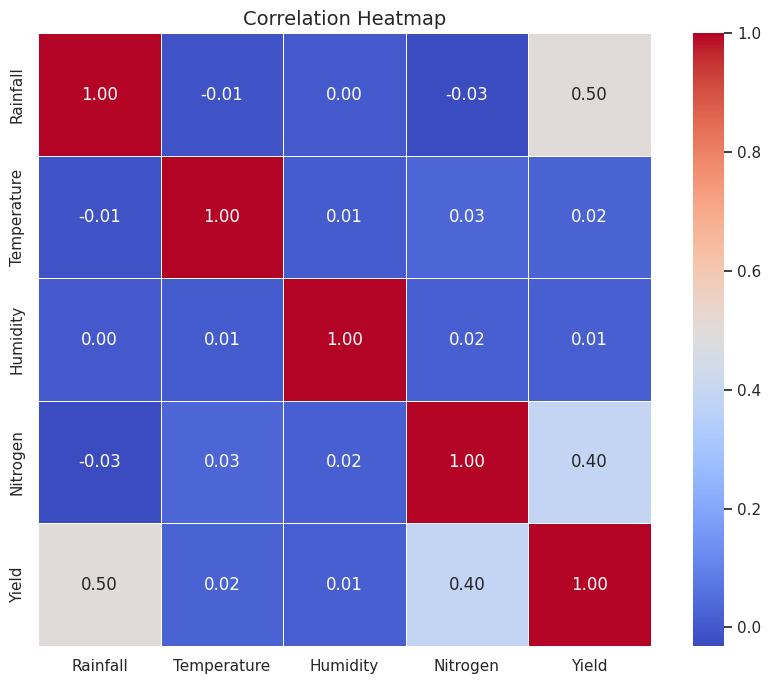


Top 3 Features Most Correlated with Yield:
Rainfall       0.498788
Nitrogen       0.395801
Temperature    0.023503
Name: Yield, dtype: float64


In [11]:
# Correlation matrix (numerical features only)
num_df = df.select_dtypes(include=np.number)
corr_matrix = num_df.corr()
print("Correlation Matrix:")
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top 3 features correlated with Yield
yield_corr = corr_matrix['Yield'].drop('Yield').abs().sort_values(ascending=False)
print("\nTop 3 Features Most Correlated with Yield:")
print(yield_corr.head(3))


### Q10. Group-Based Analysis

Average Yield by Crop Type:
Crop_Type
Wheat        5.518
Sugarcane    5.445
Maize        5.439
Cotton       5.434
Rice         5.369
Name: Yield, dtype: float64

Highest yielding crop: Wheat (5.518 ton/hectare)

Average Yield by Soil Type:
Soil_Type
Clay     5.509
Sandy    5.453
Silty    5.440
Loamy    5.347
Name: Yield, dtype: float64

Highest yielding soil type: Clay (5.509 ton/hectare)


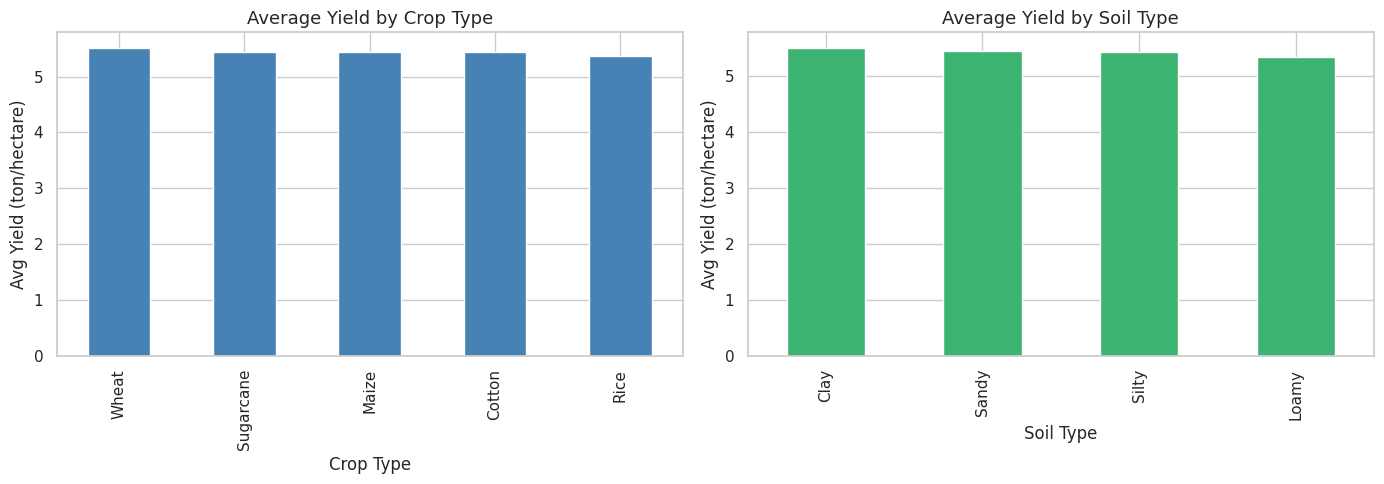

In [12]:
# Average yield per crop type
crop_yield = df.groupby('Crop_Type')['Yield'].mean().sort_values(ascending=False)
print("Average Yield by Crop Type:")
print(crop_yield.round(3))
print(f"\nHighest yielding crop: {crop_yield.idxmax()} ({crop_yield.max():.3f} ton/hectare)")

print()

# Average yield per soil type
soil_yield = df.groupby('Soil_Type')['Yield'].mean().sort_values(ascending=False)
print("Average Yield by Soil Type:")
print(soil_yield.round(3))
print(f"\nHighest yielding soil type: {soil_yield.idxmax()} ({soil_yield.max():.3f} ton/hectare)")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
crop_yield.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Average Yield by Crop Type', fontsize=13)
axes[0].set_ylabel('Avg Yield (ton/hectare)')
axes[0].set_xlabel('Crop Type')

soil_yield.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Average Yield by Soil Type', fontsize=13)
axes[1].set_ylabel('Avg Yield (ton/hectare)')
axes[1].set_xlabel('Soil Type')

plt.tight_layout()
plt.show()



### Part C: Data Preparation

### Q11. Feature Encoding

In [13]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", cat_cols)

# Drop rows with missing values before encoding
df_clean = df.dropna().copy()

# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=False)
print(f"\nShape after One-Hot Encoding: {df_encoded.shape}")
print("\nFirst 5 rows of transformed dataset:")
df_encoded.head()


Categorical Columns: ['Crop_Type', 'Soil_Type', 'Region', 'Season', 'Irrigation', 'Fertilizer']

Shape after One-Hot Encoding: (1398, 27)

First 5 rows of transformed dataset:


,Rainfall,Temperature,Humidity,Nitrogen,Yield,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,...,Region_West,Season_Kharif,Season_Rabi,Season_Zaid,Irrigation_Drip,Irrigation_Flood,Irrigation_Sprinkler,Fertilizer_Chemical,Fertilizer_Mixed,Fertilizer_Organic
0,93.7,22.9,69.0,115.0,5.13,False,False,False,False,True,...,False,True,False,False,False,False,True,True,False,False
3,72.3,26.8,69.4,44.0,4.35,False,True,False,False,False,...,False,True,False,False,False,False,True,True,False,False
4,119.9,26.3,44.3,48.0,4.88,False,True,False,False,False,...,True,True,False,False,False,True,False,False,False,True
8,136.2,31.3,58.5,111.0,6.26,False,False,True,False,False,...,False,False,True,False,True,False,False,False,True,False
9,215.7,26.2,70.8,55.0,6.92,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True


### Q12. Feature Selection

In [14]:
# Target variable
target = 'Yield'

# Features (X) and target (y)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print(f"Target variable: '{target}'")
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target  (y) shape:  {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())


Target variable: 'Yield'

Features (X) shape: (1398, 26)
Target  (y) shape:  (1398,)

Feature columns (26):
['Rainfall', 'Temperature', 'Humidity', 'Nitrogen', 'Crop_Type_Cotton', 'Crop_Type_Maize', 'Crop_Type_Rice', 'Crop_Type_Sugarcane', 'Crop_Type_Wheat', 'Soil_Type_Clay', 'Soil_Type_Loamy', 'Soil_Type_Sandy', 'Soil_Type_Silty', 'Region_East', 'Region_North', 'Region_South', 'Region_West', 'Season_Kharif', 'Season_Rabi', 'Season_Zaid', 'Irrigation_Drip', 'Irrigation_Flood', 'Irrigation_Sprinkler', 'Fertilizer_Chemical', 'Fertilizer_Mixed', 'Fertilizer_Organic']



### Part D: Machine Learning

### Q13. Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train-Test Split (80% / 20%)")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test  shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test  shape: {y_test.shape}")


Train-Test Split (80% / 20%)
  X_train shape: (1118, 26)
  X_test  shape: (280, 26)
  y_train shape: (1118,)
  y_test  shape: (280,)


### Q14. Linear Regression Model

Intercept: 1.9796

Model Coefficients (sorted):
             Feature  Coefficient
      Soil_Type_Clay     0.096527
        Region_North     0.090727
 Crop_Type_Sugarcane     0.052888
  Fertilizer_Organic     0.040654
    Irrigation_Flood     0.040376
     Crop_Type_Wheat     0.023561
       Season_Kharif     0.023372
            Nitrogen     0.018954
        Region_South     0.018830
            Rainfall     0.015061
    Crop_Type_Cotton     0.012046
    Fertilizer_Mixed     0.010810
     Crop_Type_Maize     0.004743
         Temperature     0.001827
            Humidity    -0.000410
         Season_Rabi    -0.010075
         Season_Zaid    -0.013297
     Irrigation_Drip    -0.017435
     Soil_Type_Silty    -0.020964
Irrigation_Sprinkler    -0.022941
     Soil_Type_Sandy    -0.024262
         Region_East    -0.042698
     Soil_Type_Loamy    -0.051301
 Fertilizer_Chemical    -0.051465
         Region_West    -0.066859
      Crop_Type_Rice    -0.093237

Feature with highest positive coe

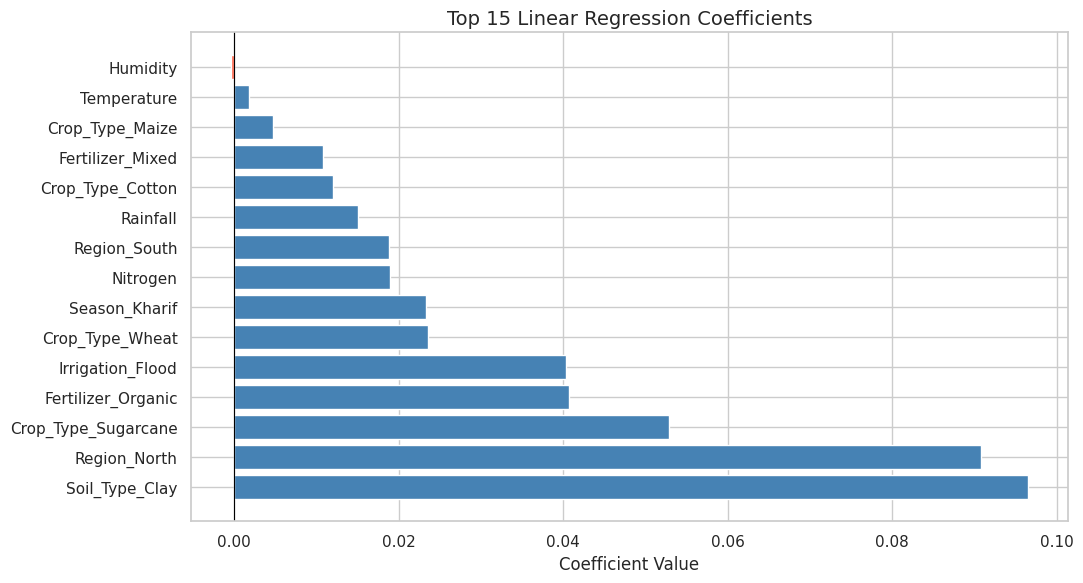

In [16]:
from sklearn.linear_model import LinearRegression

# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Intercept
print(f"Intercept: {lr.intercept_:.4f}")
print()

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients (sorted):")
print(coef_df.to_string(index=False))
print()

# Highest positive coefficient
top_feature = coef_df[coef_df['Coefficient'] > 0].iloc[0]
print(f"Feature with highest positive coefficient: {top_feature['Feature']} ({top_feature['Coefficient']:.4f})")

# Plot top 15 coefficients
plt.figure(figsize=(11, 6))
top15 = coef_df.head(15)
colors = ['steelblue' if c > 0 else 'tomato' for c in top15['Coefficient']]
plt.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Linear Regression Coefficients', fontsize=14)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


### Model Evaluation

Model Performance on Test Set:
  MAE  : 0.6463
  RMSE : 0.8150
  R²   : 0.4037


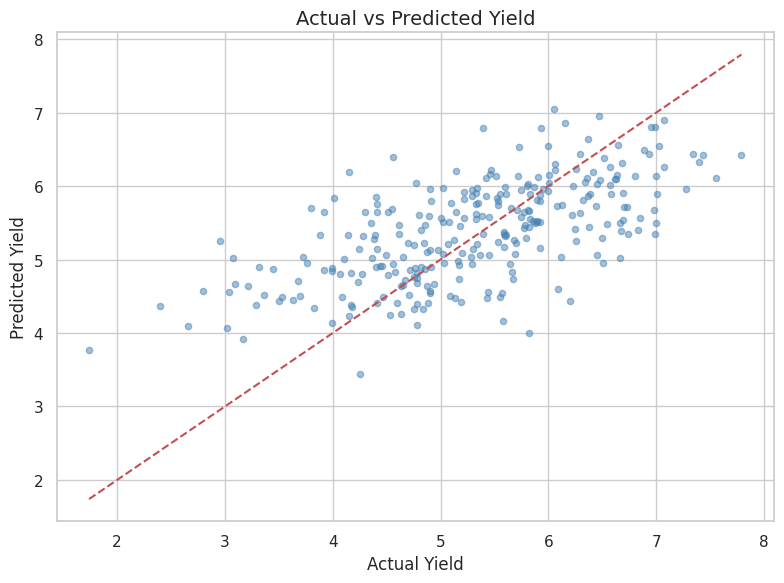

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Model Performance on Test Set:")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.title('Actual vs Predicted Yield', fontsize=14)
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.tight_layout()
plt.show()
